# **LABORATORIO 2 DE REGRESION LOGISTICA CON EL DATASET DE Intrusion Detection Network Dataset (UNSW-NB15)**
Este dataset corresponde al área de Cybersecurity y está diseñado para la detección de intrusiones en redes informáticas.

Cada fila representa una conexión o flujo de tráfico de red entre dispositivos.
El dataset almacena información sobre:

* protocolos de red
* paquetes enviados
* bytes transferidos
* tiempos de conexión
* comportamiento TCP/HTTP/FTP
* métricas estadísticas del tráfico

El objetivo principal es identificar si una conexión es:

* Normal -> 0
* Maliciosa (ataque) -> 1

y clasificar distintos tipos de ataques informáticos mediante la regresion logistica o binaria y estos son los campos:

* id -> Identificador único del registro (Entero)
* dur -> Duración de la conexión de red (Float)
* proto -> Protocolo utilizado como TCP, UDP o ICMP (Categórico/String)
* service -> Servicio de red utilizado como HTTP, FTP, DNS, SMTP, etc.(Categórico/String)
* state -> Estado de la conexión TCP (Categórico/String)
* spkts -> Cantidad de paquetes enviados desde el origen (Entero)
* dpkts -> Cantidad de paquetes enviados desde el destino (Entero)
* sbytes -> Bytes enviados desde el origen (Entero)
* dbytes -> Bytes enviados desde el destino (Entero)
* rate -> Velocidad o tasa de transferencia de datos (Float)
* sttl -> Valor TTL del origen (Entero)
* dttl -> Valor TTL del destino (Entero)
* sload -> Carga de datos enviada desde el origen (Float)
* dload -> Carga de datos enviada desde el destino (Float)
* sloss -> Cantidad de paquetes perdidos en el origen (Entero)
* dloss -> Cantidad de paquetes perdidos en el destino (Entero)
* sinpkt -> Tiempo entre paquetes enviados desde el origen (Float)
* dinpkt -> Tiempo entre paquetes enviados desde el destino (Float)
* sjit -> Variación temporal (jitter) de paquetes del origen (Float)
* djit -> Variación temporal (jitter) de paquetes del destino (Float)
* swin -> Tamaño de ventana TCP del origen (Entero)
* stcpb -> Número de secuencia TCP del origen (Entero)
* dtcpb -> Número de secuencia TCP del destino (Entero)
* dwin -> Tamaño de ventana TCP del destino (Entero)
* tcprtt -> Tiempo Round Trip Time de TCP (Float)
* synack -> Tiempo entre SYN y ACK (Float)
* ackdat -> Tiempo entre ACK y envío de datos (Float)
* smean -> Tamaño promedio de paquetes enviados desde origen (Entero)
* dmean -> Tamaño promedio de paquetes enviados desde destino (Entero)
* trans_depth -> Profundidad de transacción HTTP (Entero)
* response_body_len -> Tamaño del cuerpo de respuesta HTTP (Entero)
* ct_srv_src -> Número de conexiones con mismo servicio y origen (Entero)
* ct_state_ttl -> Conteo de conexiones con mismo estado y TTL (Entero)
* ct_dst_ltm -> Número de conexiones recientes al destino (Entero)
* ct_src_dport_ltm -> Conexiones recientes al mismo puerto destino (Entero)
* ct_dst_sport_ltm -> Conexiones recientes al mismo puerto origen (Entero)
* ct_dst_src_ltm -> Conexiones recientes entre mismo origen y destino (Entero)
* is_ftp_login -> Indica si hubo inicio de sesión FTP (Binario 0/1)
* ct_ftp_cmd -> Cantidad de comandos FTP utilizados (Entero)
* ct_flw_http_mthd -> Cantidad de métodos HTTP utilizados (Entero)
* ct_src_ltm -> Número de conexiones recientes desde el origen (Entero)
* ct_srv_dst -> Número de conexiones al mismo servicio y destino (Entero)
* is_sm_ips_ports -> Indica si IP y puerto origen/destino son iguales (Binario 0/1)
* attack_cat -> Categoría del ataque informático (Categórico/String)
* label -> Clase final de la conexión: normal o ataque (Binario/Categórico)

In [ ]:
#from google.colab import drive
#drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [38]:
# se utiliza para el manejo de rutas y directorios.
import os
import pandas as pd
import numpy as np
from matplotlib import pyplot

In [ ]:
# df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/machine learning/datasetslabs/UNSW_NB15_training-set - copia.csv', delimiter=',')
df = pd.read_csv('UNSW_NB15_training-set - copia.csv', delimiter=',')
df

,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,...,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
0,1,0.121478,tcp,NaN,FIN,6,4,258,172,74.087490,...,1,1,0,0,0,1,1,0,Normal,0
1,2,0.649902,tcp,NaN,FIN,14,38,734,42014,78.473372,...,1,2,0,0,0,1,6,0,Normal,0
2,3,1.623129,tcp,NaN,FIN,8,16,364,13186,14.170161,...,1,3,0,0,0,2,6,0,Normal,0
3,4,1.681642,tcp,ftp,FIN,12,12,628,770,13.677108,...,1,3,1,1,0,2,1,0,Normal,0
4,5,0.449454,tcp,NaN,FIN,10,6,534,268,33.373826,...,1,40,0,0,0,2,39,0,Normal,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
175336,175337,0.000009,udp,dns,INT,2,0,114,0,111111.107200,...,13,24,0,0,0,24,24,0,Generic,1
175337,175338,0.505762,tcp,NaN,FIN,10,8,620,354,33.612649,...,1,2,0,0,0,1,1,0,Shellcode,1
175338,175339,0.000009,udp,dns,INT,2,0,114,0,111111.107200,...,3,13,0,0,0,3,12,0,Generic,1
175339,175340,0.000009,udp,dns,INT,2,0,114,0,111111.107200,...,14,30,0,0,0,30,30,0,Generic,1


## **COLUMNA PROTO QUE ES TEXTO A NUMERO**

In [40]:
# Verificar si existen valores nulos
if df['proto'].isnull().any():
    print("La columna contiene valores nulos")
else:
    print("La columna no contiene valores nulos")

La columna no contiene valores nulos


In [41]:
# Contar registros por categoría
agrupadas = df['proto'].value_counts()
print(agrupadas)

proto
tcp       79946
udp       63283
unas      12084
arp        2859
ospf       2595
          ...  
argus        98
netblt       98
igmp         18
icmp         15
rtp           1
Name: count, Length: 133, dtype: int64


In [42]:
print(df['proto'].unique())

['tcp' 'udp' 'arp' 'ospf' 'icmp' 'igmp' 'rtp' 'ddp' 'ipv6-frag' 'cftp'
 'wsn' 'pvp' 'wb-expak' 'mtp' 'pri-enc' 'sat-mon' 'cphb' 'sun-nd' 'iso-ip'
 'xtp' 'il' 'unas' 'mfe-nsp' '3pc' 'ipv6-route' 'idrp' 'bna' 'swipe'
 'kryptolan' 'cpnx' 'rsvp' 'wb-mon' 'vmtp' 'ib' 'dgp' 'eigrp' 'ax.25'
 'gmtp' 'pnni' 'sep' 'pgm' 'idpr-cmtp' 'zero' 'rvd' 'mobile' 'narp' 'fc'
 'pipe' 'ipcomp' 'ipv6-no' 'sat-expak' 'ipv6-opts' 'snp' 'ipcv'
 'br-sat-mon' 'ttp' 'tcf' 'nsfnet-igp' 'sprite-rpc' 'aes-sp3-d' 'sccopmce'
 'sctp' 'qnx' 'scps' 'etherip' 'aris' 'pim' 'compaq-peer' 'vrrp' 'iatp'
 'stp' 'l2tp' 'srp' 'sm' 'isis' 'smp' 'fire' 'ptp' 'crtp' 'sps'
 'merit-inp' 'idpr' 'skip' 'any' 'larp' 'ipip' 'micp' 'encap' 'ifmp'
 'tp++' 'a/n' 'ipv6' 'i-nlsp' 'ipx-n-ip' 'sdrp' 'tlsp' 'gre' 'mhrp' 'ddx'
 'ippc' 'visa' 'secure-vmtp' 'uti' 'vines' 'crudp' 'iplt' 'ggp' 'ip'
 'ipnip' 'st2' 'argus' 'bbn-rcc' 'egp' 'emcon' 'igp' 'nvp' 'pup' 'xnet'
 'chaos' 'mux' 'dcn' 'hmp' 'prm' 'trunk-1' 'xns-idp' 'leaf-1' 'leaf-2'
 'rdp' 'irtp

In [43]:
# Lista de tus 133 categorías únicas
lista_protocolos = ['tcp', 'udp', 'arp', 'ospf', 'icmp', 'igmp', 'rtp', 'ddp', 'ipv6-frag', 'cftp', 'wsn', 'pvp', 'wb-expak', 'mtp', 'pri-enc', 'sat-mon', 'cphb', 'sun-nd', 'iso-ip', 'xtp', 'il', 'unas', 'mfe-nsp', '3pc', 'ipv6-route', 'idrp', 'bna', 'swipe', 'kryptolan', 'cpnx', 'rsvp', 'wb-mon', 'vmtp', 'ib', 'dgp', 'eigrp', 'ax.25', 'gmtp', 'pnni', 'sep', 'pgm', 'idpr-cmtp', 'zero', 'rvd', 'mobile', 'narp', 'fc', 'pipe', 'ipcomp', 'ipv6-no', 'sat-expak', 'ipv6-opts', 'snp', 'ipcv', 'br-sat-mon', 'ttp', 'tcf', 'nsfnet-igp', 'sprite-rpc', 'aes-sp3-d', 'sccopmce', 'sctp', 'qnx', 'scps', 'etherip', 'aris', 'pim', 'compaq-peer', 'vrrp', 'iatp', 'stp', 'l2tp', 'srp', 'sm', 'isis', 'smp', 'fire', 'ptp', 'crtp', 'sps', 'merit-inp', 'idpr', 'skip', 'any', 'larp', 'ipip', 'micp', 'encap', 'ifmp', 'tp++', 'a/n', 'ipv6', 'i-nlsp', 'ipx-n-ip', 'sdrp', 'tlsp', 'gre', 'mhrp', 'ddx', 'ippc', 'visa', 'secure-vmtp', 'uti', 'vines', 'crudp', 'iplt', 'ggp', 'ip', 'ipnip', 'st2', 'argus', 'bbn-rcc', 'egp', 'emcon', 'igp', 'nvp', 'pup', 'xnet', 'chaos', 'mux', 'dcn', 'hmp', 'prm', 'trunk-1', 'xns-idp', 'leaf-1', 'leaf-2', 'rdp', 'irtp', 'iso-tp4', 'netblt', 'trunk-2', 'cbt']

# Creamos un diccionario donde cada protocolo tiene un ID (ej: 'tcp': 0, 'udp': 1...)
proto_to_numeric = {proto: index for index, proto in enumerate(lista_protocolos, start=1)}

# Aplicamos el mapeo al DataFrame
df['proto_num'] = df['proto'].map(proto_to_numeric)

In [44]:
df

,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,...,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label,proto_num
0,1,0.121478,tcp,NaN,FIN,6,4,258,172,74.087490,...,1,0,0,0,1,1,0,Normal,0,1
1,2,0.649902,tcp,NaN,FIN,14,38,734,42014,78.473372,...,2,0,0,0,1,6,0,Normal,0,1
2,3,1.623129,tcp,NaN,FIN,8,16,364,13186,14.170161,...,3,0,0,0,2,6,0,Normal,0,1
3,4,1.681642,tcp,ftp,FIN,12,12,628,770,13.677108,...,3,1,1,0,2,1,0,Normal,0,1
4,5,0.449454,tcp,NaN,FIN,10,6,534,268,33.373826,...,40,0,0,0,2,39,0,Normal,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
175336,175337,0.000009,udp,dns,INT,2,0,114,0,111111.107200,...,24,0,0,0,24,24,0,Generic,1,2
175337,175338,0.505762,tcp,NaN,FIN,10,8,620,354,33.612649,...,2,0,0,0,1,1,0,Shellcode,1,1
175338,175339,0.000009,udp,dns,INT,2,0,114,0,111111.107200,...,13,0,0,0,3,12,0,Generic,1,2
175339,175340,0.000009,udp,dns,INT,2,0,114,0,111111.107200,...,30,0,0,0,30,30,0,Generic,1,2


## **COLUMNA SERVICE QUE ES TEXTO A NUMERO**

In [45]:
# Verificar si existen valores nulos
if df['service'].isnull().any():
    print("La columna contiene valores nulos")
else:
    print("La columna no contiene valores nulos")

La columna contiene valores nulos


In [46]:
# Contar registros por categoría
agrupadas = df['service'].value_counts()
print(agrupadas)

service
dns        47294
http       18724
smtp        5058
ftpdata     3995
ftp         3428
ssh         1302
pop3        1105
dhcp          94
snmp          80
ssl           56
irc           25
radius        12
Name: count, dtype: int64


In [47]:
import numpy as np

# 1. Lista de tus 12 servicios únicos
lista_servicios = ['dns', 'http', 'smtp', 'ftpdata', 'ftp', 'ssh', 'pop3', 'dhcp', 'snmp', 'ssl', 'irc', 'radius']

# 2. Creamos el diccionario iniciando en 1
service_to_numeric = {service: index for index, service in enumerate(lista_servicios, start=1)}

# 3. Mapeamos, reemplazamos los nulos por 0 y convertimos a entero
df['service_num'] = df['service'].map(service_to_numeric).fillna(0).astype(int)

In [48]:
df

,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,...,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label,proto_num,service_num
0,1,0.121478,tcp,NaN,FIN,6,4,258,172,74.087490,...,0,0,0,1,1,0,Normal,0,1,0
1,2,0.649902,tcp,NaN,FIN,14,38,734,42014,78.473372,...,0,0,0,1,6,0,Normal,0,1,0
2,3,1.623129,tcp,NaN,FIN,8,16,364,13186,14.170161,...,0,0,0,2,6,0,Normal,0,1,0
3,4,1.681642,tcp,ftp,FIN,12,12,628,770,13.677108,...,1,1,0,2,1,0,Normal,0,1,5
4,5,0.449454,tcp,NaN,FIN,10,6,534,268,33.373826,...,0,0,0,2,39,0,Normal,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
175336,175337,0.000009,udp,dns,INT,2,0,114,0,111111.107200,...,0,0,0,24,24,0,Generic,1,2,1
175337,175338,0.505762,tcp,NaN,FIN,10,8,620,354,33.612649,...,0,0,0,1,1,0,Shellcode,1,1,0
175338,175339,0.000009,udp,dns,INT,2,0,114,0,111111.107200,...,0,0,0,3,12,0,Generic,1,2,1
175339,175340,0.000009,udp,dns,INT,2,0,114,0,111111.107200,...,0,0,0,30,30,0,Generic,1,2,1


## **COLUMNA STATE QUE ES TEXTO A NUMERO**

In [49]:
# Verificar si existen valores nulos
if df['state'].isnull().any():
    print("La columna contiene valores nulos")
else:
    print("La columna no contiene valores nulos")

La columna no contiene valores nulos


In [50]:
# Contar registros por categoría
agrupadas = df['state'].value_counts()
print(agrupadas)

state
INT    82275
FIN    77825
CON    13152
REQ     1991
RST       83
ECO       12
PAR        1
URN        1
no         1
Name: count, dtype: int64


In [51]:
# Lista de tus 133 categorías únicas
lista_state = ['INT', 'FIN', 'CON', 'REQ', 'RST', 'ECO', 'PAR', 'URN', 'no']

# Creamos un diccionario donde cada protocolo tiene un ID (ej: 'tcp': 0, 'udp': 1...)
state_to_numeric = {state: index for index, state in enumerate(lista_state, start=1)}

# Aplicamos el mapeo al DataFrame
df['state_num'] = df['state'].map(state_to_numeric)

In [52]:
df

,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,...,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label,proto_num,service_num,state_num
0,1,0.121478,tcp,NaN,FIN,6,4,258,172,74.087490,...,0,0,1,1,0,Normal,0,1,0,2
1,2,0.649902,tcp,NaN,FIN,14,38,734,42014,78.473372,...,0,0,1,6,0,Normal,0,1,0,2
2,3,1.623129,tcp,NaN,FIN,8,16,364,13186,14.170161,...,0,0,2,6,0,Normal,0,1,0,2
3,4,1.681642,tcp,ftp,FIN,12,12,628,770,13.677108,...,1,0,2,1,0,Normal,0,1,5,2
4,5,0.449454,tcp,NaN,FIN,10,6,534,268,33.373826,...,0,0,2,39,0,Normal,0,1,0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
175336,175337,0.000009,udp,dns,INT,2,0,114,0,111111.107200,...,0,0,24,24,0,Generic,1,2,1,1
175337,175338,0.505762,tcp,NaN,FIN,10,8,620,354,33.612649,...,0,0,1,1,0,Shellcode,1,1,0,2
175338,175339,0.000009,udp,dns,INT,2,0,114,0,111111.107200,...,0,0,3,12,0,Generic,1,2,1,1
175339,175340,0.000009,udp,dns,INT,2,0,114,0,111111.107200,...,0,0,30,30,0,Generic,1,2,1,1


In [53]:
# Variables
X = df.drop(['id', 'attack_cat', 'label', 'proto', 'service', 'state'], axis=1)
y = df['label']
X

,dur,spkts,dpkts,sbytes,dbytes,rate,sttl,dttl,sload,dload,...,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,proto_num,service_num,state_num
0,0.121478,6,4,258,172,74.087490,252,254,1.415894e+04,8495.365234,...,1,0,0,0,1,1,0,1,0,2
1,0.649902,14,38,734,42014,78.473372,62,252,8.395112e+03,503571.312500,...,2,0,0,0,1,6,0,1,0,2
2,1.623129,8,16,364,13186,14.170161,62,252,1.572272e+03,60929.230470,...,3,0,0,0,2,6,0,1,0,2
3,1.681642,12,12,628,770,13.677108,62,252,2.740179e+03,3358.622070,...,3,1,1,0,2,1,0,1,5,2
4,0.449454,10,6,534,268,33.373826,254,252,8.561499e+03,3987.059814,...,40,0,0,0,2,39,0,1,0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
175336,0.000009,2,0,114,0,111111.107200,254,0,5.066666e+07,0.000000,...,24,0,0,0,24,24,0,2,1,1
175337,0.505762,10,8,620,354,33.612649,254,252,8.826286e+03,4903.492188,...,2,0,0,0,1,1,0,1,0,2
175338,0.000009,2,0,114,0,111111.107200,254,0,5.066666e+07,0.000000,...,13,0,0,0,3,12,0,2,1,1
175339,0.000009,2,0,114,0,111111.107200,254,0,5.066666e+07,0.000000,...,30,0,0,0,30,30,0,2,1,1


## Separar 80% de entrenamiento y 20% de prueba

In [54]:
from sklearn.model_selection import train_test_split
# Separar entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

## Definicion de la Funcion de Normalizacion

In [55]:
def normalizarCaracteristicas(X):
    X_norm = X.copy()
    mu = np.zeros(X.shape[1])
    sigma = np.zeros(X.shape[1])

    mu = np.mean(X, axis = 0)
    sigma = np.std(X, axis = 0)
    X_norm = (X - mu) / sigma

    return X_norm, mu, sigma

Normalizacion del Entrenamiento

In [56]:
# llama featureNormalize con los datos cargados
X_train_norm, mu, sigma = normalizarCaracteristicas(X_train)
print('Media calculada:')
print(mu)
print('==============================================')
print('Desviación estandar calculada:')
print(sigma)
print('==============================================')
print(X_train_norm)

Media calculada:
dur                  1.358615e+00
spkts                2.006709e+01
dpkts                1.894439e+01
sbytes               8.477117e+03
dbytes               1.492050e+04
rate                 9.509676e+04
sttl                 1.794426e+02
dttl                 7.957093e+01
sload                7.305923e+07
dload                6.756609e+05
sloss                4.820634e+00
dloss                6.950125e+00
sinpkt               9.901219e+02
dinpkt               8.874953e+01
sjit                 4.990001e+03
djit                 6.073599e+02
swin                 1.163341e+02
stcpb                9.702978e+08
dtcpb                9.698225e+08
dwin                 1.150629e+02
tcprtt               4.134096e-02
synack               2.096145e-02
ackdat               2.037951e-02
smean                1.364283e+02
dmean                1.244460e+02
trans_depth          1.054737e-01
response_body_len    2.117814e+03
ct_srv_src           9.303061e+00
ct_state_ttl         1.303304e+

Normalizacion de la Prueba

In [57]:
# llama featureNormalize con los datos cargados
X_test_norm, mu, sigma = normalizarCaracteristicas(X_test)
print('Media calculada:')
print(mu)
print('==============================================')
print('Desviación estandar calculada:')
print(sigma)
print('==============================================')
print(X_test_norm)

Media calculada:
dur                  1.362484e+00
spkts                2.122493e+01
dpkts                1.907038e+01
sbytes               1.031571e+04
dbytes               1.496260e+04
rate                 9.664385e+04
sttl                 1.799644e+02
dttl                 7.976412e+01
sload                7.503320e+07
dload                6.533847e+05
sloss                5.482449e+00
dloss                6.939548e+00
sinpkt               9.693970e+02
dinpkt               8.608343e+01
sjit                 4.921267e+03
djit                 5.923300e+02
swin                 1.159503e+02
stcpb                9.650612e+08
dtcpb                9.650951e+08
dwin                 1.148164e+02
tcprtt               4.161437e-02
synack               2.125643e-02
ackdat               2.035794e-02
smean                1.380456e+02
dmean                1.230830e+02
trans_depth          1.080156e-01
response_body_len    2.250199e+03
ct_srv_src           9.319941e+00
ct_state_ttl         1.307679e+

## **Definir la funcion de la Sigmoide**

In [58]:
def sigmoid(z):
    # Calcula la sigmoide de una entrada z
    # convierte la intrada a un arreglo numpy
    z = np.array(z)

    g = np.zeros(z.shape)

    g = 1 / (1 + np.exp(-z))

    return g

Se calcula el valor de la sigmoide aplicando la funcion sigmoid con z=0, se debe obtener un resultado de 0.5. RE recomienda experimentar con otros valores de z.

In [59]:
# Prueba la implementacion de la funcion sigmoid
z = 0
g = sigmoid(z)

print('g(', z, ') = ', g)

g( 0 ) =  0.5


## **Función de Costo y Gradiente**

Se implementa la funcion cost y gradient, para la regresión logistica. Antes de continuar es importante agregar el termino de intercepcion a X_train_norm y X_test_norm.

In [60]:
# Configurar la matriz adecuadamente, y agregar una columna de unos que corresponde al termino de intercepción.
m, n = X_train_norm.shape
# Agraga el termino de intercepción a A
XTRNC = np.concatenate([np.ones((m, 1)), X_train_norm], axis=1)

print(XTRNC)

[[ 1.         -0.12989981 -0.0766563  ... -0.35254546  0.8555255
   0.54495586]
 [ 1.         -0.20999167 -0.13757265 ...  0.6242681  -0.64595116
  -0.9311013 ]
 [ 1.         -0.06794667 -0.01573995 ... -0.35254546 -0.64595116
   0.54495586]
 ...
 [ 1.         -0.20999182 -0.13757265 ... -0.30603053  0.10478717
  -0.9311013 ]
 [ 1.         -0.20999244 -0.13757265 ... -0.30603053  0.10478717
  -0.9311013 ]
 [ 1.         -0.20999167 -0.13757265 ... -0.30603053  0.10478717
  -0.9311013 ]]


In [61]:
print(m)
print(n)

140272
42


In [62]:
# Configurar la matriz adecuadamente, y agregar una columna de unos que corresponde al termino de intercepción.
m, n = X_test_norm.shape
# Agraga el termino de intercepción a A
XTENC = np.concatenate([np.ones((m, 1)), X_test_norm], axis=1)
XTENC

array([[ 1.        ,  0.21070738,  1.3410889 , ..., -0.35038179,
        -0.64954341,  0.54886004],
       [ 1.        , -0.20891249, -0.12232157, ..., -0.30334112,
         0.10121754, -0.92743792],
       [ 1.        ,  0.67865893,  0.09400867, ..., -0.35038179,
        -0.64954341,  0.54886004],
       ...,
       [ 1.        , -0.05419338, -0.04596972, ..., -0.35038179,
         0.85197848,  0.54886004],
       [ 1.        , -0.20864446, -0.10959626, ..., -0.30334112,
        -0.64954341,  2.02515801],
       [ 1.        , -0.08288906, -0.07142034, ..., -0.35038179,
        -0.64954341,  0.54886004]])

In [63]:
print(m)
print(n)

35069
42


## **Definicion de Funcion de Costo**

In [64]:
def calcularCosto(theta, X, y):
    # Inicializar algunos valores utiles
    m = y.size  # numero de ejemplos de entrenamiento

    J = 0
    h = sigmoid(X.dot(theta.T))

    # Clip h to avoid log(0) or log(1-1)
    epsilon = 1e-10
    h = np.clip(h, epsilon, 1 - epsilon)

    J = (1 / m) * np.sum(-y.dot(np.log(h)) - (1 - y).dot(np.log(1 - h)))

    return J

## **Definicion del Desenso Por el Gradiente**

In [65]:
def descensoGradiente(theta, X, y, alpha, num_iters):
    # Inicializa algunos valores
    m = y.shape[0] # numero de ejemplos de entrenamiento

    # realiza una copia de theta, el cual será acutalizada por el descenso por el gradiente
    theta = theta.copy()
    J_history = []

    for i in range(num_iters):
        h = sigmoid(X.dot(theta.T))
        theta = theta - (alpha / m) * (h - y).dot(X)

        J_history.append(calcularCosto(theta, X, y))
    return theta, J_history

## **Función de Predicción**

theta calculado por el descenso por el gradiente: [ 9.31904179e-01  1.57274242e-01 -8.99622557e-03 -2.52935118e-02
  7.81675056e-02  2.20195472e-02  2.09145094e-01  7.81489204e-01
  8.00541154e-01 -1.01604597e-01 -4.96425696e-01  5.18070781e-02
  1.15096199e-02 -2.51222162e-01 -3.15487173e-02 -1.34518181e-02
 -1.83077548e-04 -2.94953992e-01 -6.92277824e-02 -5.35511858e-02
 -1.64761199e-01  3.65473038e-02 -7.72946536e-02  1.53438128e-01
 -2.99872455e-02  1.09525069e-01  1.94940462e-01 -6.05685872e-03
 -1.87801787e-01  6.10296593e-01  1.69415544e-02  1.89406461e-01
  3.61204856e-01 -3.04106456e-02  3.60478740e-03  3.60478740e-03
  1.30589704e-01  6.53188573e-02 -1.95489286e-01 -2.98382933e-01
  4.08963884e-01  4.34385886e-01 -8.67294817e-01]


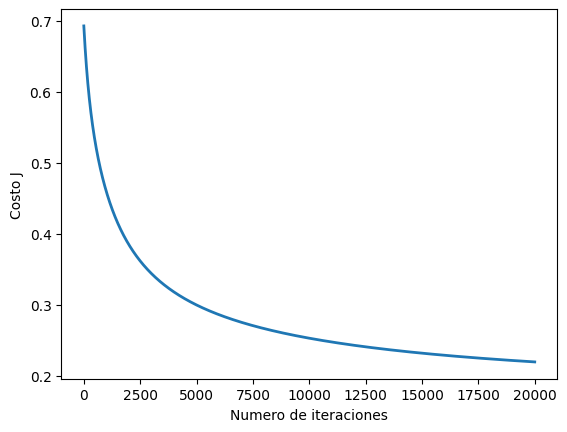

In [69]:
# Elegir algun valor para alpha (probar varias alternativas)
alpha = 0.001
num_iters = 20000

# inicializa theta y ejecuta el descenso por el gradiente
theta = np.zeros(n + 1)

# ejecuta descenso por el gradiente
theta, J_history = descensoGradiente(theta, XTRNC, y_train, alpha, num_iters)

# Grafica la convergencia del costo
pyplot.plot(np.arange(len(J_history)), J_history, lw=2)
pyplot.xlabel('Numero de iteraciones')
pyplot.ylabel('Costo J')

# Muestra los resultados del descenso por el gradiente
print('theta calculado por el descenso por el gradiente: {:s}'.format(str(theta)))

In [71]:
theta

array([ 9.31904179e-01,  1.57274242e-01, -8.99622557e-03, -2.52935118e-02,
        7.81675056e-02,  2.20195472e-02,  2.09145094e-01,  7.81489204e-01,
        8.00541154e-01, -1.01604597e-01, -4.96425696e-01,  5.18070781e-02,
        1.15096199e-02, -2.51222162e-01, -3.15487173e-02, -1.34518181e-02,
       -1.83077548e-04, -2.94953992e-01, -6.92277824e-02, -5.35511858e-02,
       -1.64761199e-01,  3.65473038e-02, -7.72946536e-02,  1.53438128e-01,
       -2.99872455e-02,  1.09525069e-01,  1.94940462e-01, -6.05685872e-03,
       -1.87801787e-01,  6.10296593e-01,  1.69415544e-02,  1.89406461e-01,
        3.61204856e-01, -3.04106456e-02,  3.60478740e-03,  3.60478740e-03,
        1.30589704e-01,  6.53188573e-02, -1.95489286e-01, -2.98382933e-01,
        4.08963884e-01,  4.34385886e-01, -8.67294817e-01])

## **Evaluación del Modelo**

In [74]:
y_test.head(10)

,label
15482,0
133349,1
80485,1
29972,0
18339,0
170500,1
165830,1
55215,1
37756,0
22160,0


In [78]:
for i in range(10):

    # Predicción usando el ejemplo i
    label = sigmoid(np.dot(XTENC[i], theta))

    # Valor real
    real_label = y_test.iloc[i]

    # Mostrar resultados
    print(f'Predicción {i+1}')
    print(f'Label real: ${real_label:.0f}')
    print(f'Label predecido en porcentaje: {label * 100}%')
    print('-----------------------------')

Predicción 1
Label real: $0
Label predecido en porcentaje: 5.346998146320985%
-----------------------------
Predicción 2
Label real: $1
Label predecido en porcentaje: 95.75615221826436%
-----------------------------
Predicción 3
Label real: $1
Label predecido en porcentaje: 79.21130425491599%
-----------------------------
Predicción 4
Label real: $0
Label predecido en porcentaje: 4.565142461093242%
-----------------------------
Predicción 5
Label real: $0
Label predecido en porcentaje: 4.825533372652682%
-----------------------------
Predicción 6
Label real: $1
Label predecido en porcentaje: 94.83654398154063%
-----------------------------
Predicción 7
Label real: $1
Label predecido en porcentaje: 95.57514429281191%
-----------------------------
Predicción 8
Label real: $1
Label predecido en porcentaje: 69.35793717616392%
-----------------------------
Predicción 9
Label real: $0
Label predecido en porcentaje: 8.884363639940347%
-----------------------------
Predicción 10
Label real: $0